In [ ]:
!pip install groq opencv-python-headless pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.0 MB/s eta 0:00:00


In [ ]:
# Step 2: Imports
import cv2
import base64
import time
import io
from PIL import Image
from groq import Groq
from IPython.display import display, Markdown, Image as IPImage
from google.colab import files

print("Libraries imported!")

Libraries imported!


In [ ]:
# Get FREE key from: https://console.groq.com → Sign in → API Keys → Create

API_KEY = " Your API Key"  # <-- paste your key here

client = Groq(api_key=API_KEY)
print("Groq client ready!")

Groq client ready!


In [ ]:

uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {VIDEO_PATH}")

Saving obstacle.mp4 to obstacle.mp4
Uploaded: obstacle.mp4


In [ ]:
NUM_FRAMES = 5   # <-- change this to any number you want
# ----------------------------------------

def extract_frames(video_path, num_frames):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    duration = total / fps
    print(f"Video: {total} frames | {fps:.1f} FPS | {duration:.1f} sec")

    indices = [int(i * total / num_frames) for i in range(num_frames)]
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            timestamp = round(idx / fps, 2)
            frames.append((timestamp, frame_rgb))
    cap.release()
    print(f"Extracted {len(frames)} frames.")
    return frames

frames = extract_frames(VIDEO_PATH, NUM_FRAMES)

Video: 93 frames | 16.0 FPS | 5.8 sec
Extracted 5 frames.


In [ ]:
def frame_to_base64(frame_array):
    pil_img = Image.fromarray(frame_array)
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG')
    return base64.b64encode(buf.getvalue()).decode('utf-8')

# Function to ask Groq about a frame
def analyze_frame(frame_array):
    b64 = frame_to_base64(frame_array)

    response = client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",  # free Groq vision model
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{b64}"}
                    },
                    {
                        "type": "text",
                        "text": """You are an autonomous vehicle navigation assistant.
Look at this frame from a driving video and answer:
1. What obstacles or hazards are visible?
2. How should the vehicle respond to avoid them?
3. What is the recommended action (e.g. brake, steer left, maintain speed)?
Keep your answer short and practical."""
                    }
                ]
            }
        ],
        max_tokens=300
    )
    return response.choices[0].message.content

print("Analyzer ready!")

Analyzer ready!


Analyzing 5 frames with Groq...


📸 Frame 1 — Timestamp: 0.0s


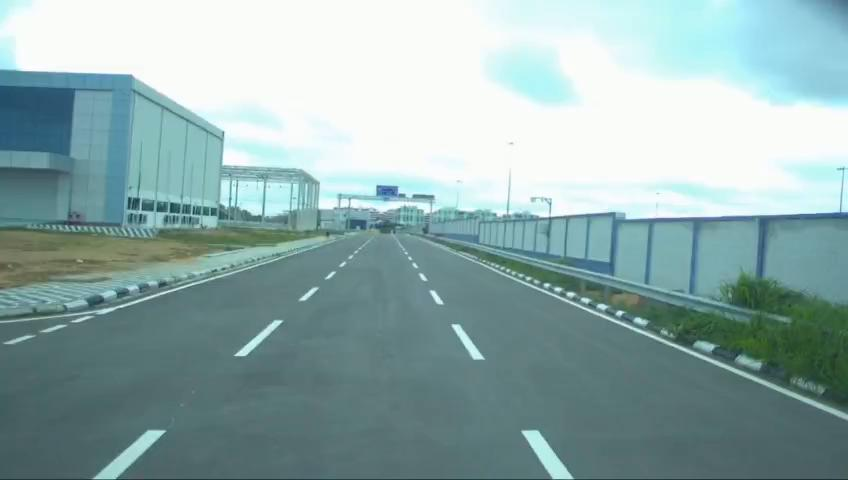

**🤖 LLM Advice:**

1. The visible obstacles or hazards are:
- A large building on the left side of the road.
- A fence on the right side of the road.

2. To avoid them, the vehicle should stay in its lane and maintain a safe distance from the obstacles.

3. The recommended action is: Maintain speed. There are no immediate hazards in the vehicle's path, and it appears to have a clear lane to drive in.

------------------------------------------------------------

📸 Frame 2 — Timestamp: 1.12s


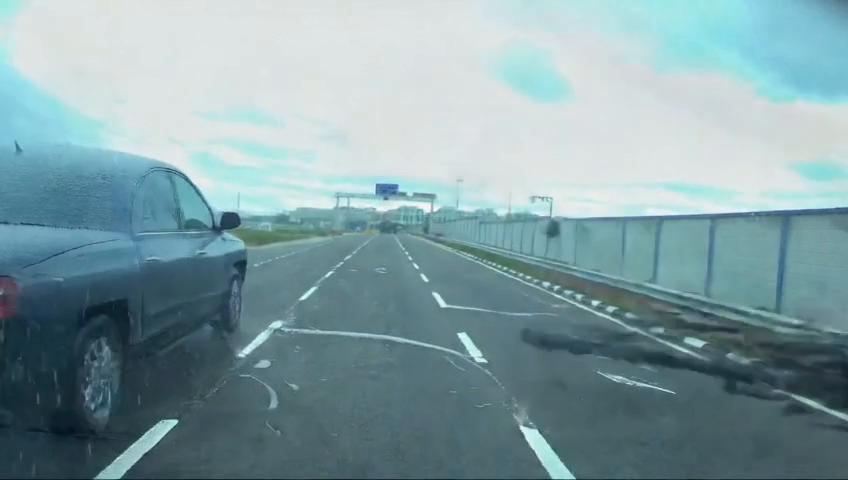

**🤖 LLM Advice:**

1. The visible obstacles or hazards are a vehicle on the left side of the road and a concrete barrier on the right side.
2. The vehicle should maintain a safe distance from the vehicle on the left and stay in its lane to avoid the concrete barrier on the right.
3. The recommended action is to **maintain speed** and **steer slightly right** to ensure a safe distance from the vehicle on the left while avoiding the barrier on the right. However, since the vehicle on the left is not an immediate hazard and there is no obstacle in the immediate path, the most appropriate action would be to **maintain speed** and **keep to the center of the lane**.

------------------------------------------------------------

📸 Frame 3 — Timestamp: 2.31s


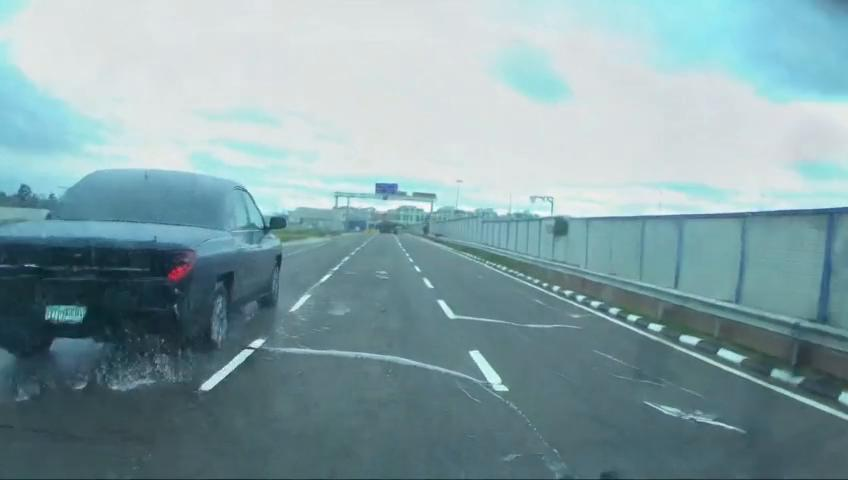

**🤖 LLM Advice:**

1. The visible hazards are a vehicle in front of the autonomous vehicle, which appears to be driving erratically or slowly and a wet road surface with a puddle.

2. To avoid these hazards, the autonomous vehicle should maintain a safe distance from the vehicle in front and slow down to navigate through the puddle safely.

3. The recommended action is to **brake** slightly to increase following distance and reduce speed to avoid hydroplaning in the puddle.

------------------------------------------------------------

📸 Frame 4 — Timestamp: 3.44s


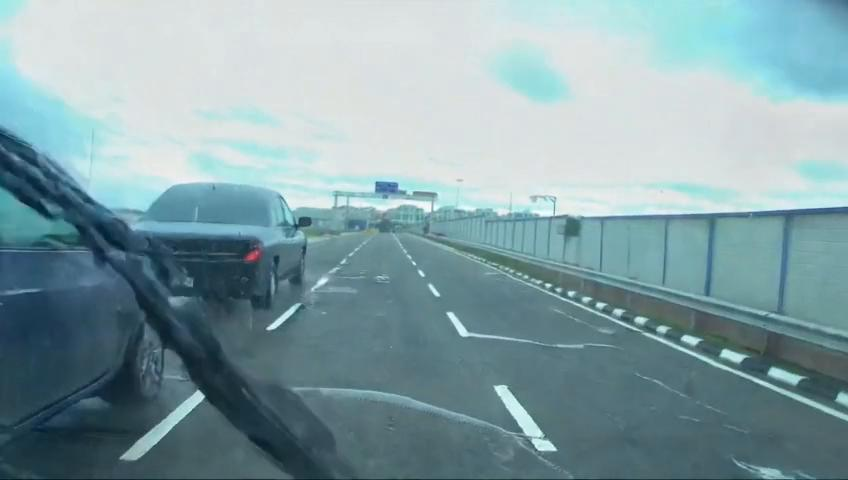

**🤖 LLM Advice:**

1. The visible obstacles or hazards are a vehicle in front and a concrete barrier to the right.
2. To avoid them, the vehicle should maintain a safe distance from the vehicle in front and stay in its lane to avoid the barrier.
3. The recommended action is to **brake** and **maintain current lane position**.

------------------------------------------------------------

📸 Frame 5 — Timestamp: 4.62s


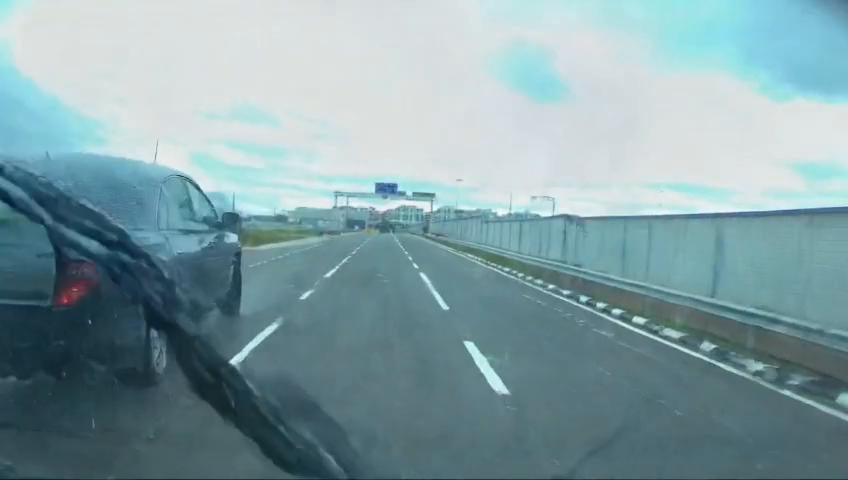

**🤖 LLM Advice:**

1. The visible obstacles or hazards are a car on the left side of the road and a concrete barrier on the right side of the road.
2. To avoid them, the vehicle should maintain a safe distance from the car on the left and stay in its current lane, avoiding the concrete barrier on the right.
3. The recommended action is to **maintain speed** and **keep to the center of the lane**.

------------------------------------------------------------

✅ Done!


In [ ]:
print(f"Analyzing {len(frames)} frames with Groq...\n")
print("=" * 60)

results = []

for i, (timestamp, frame) in enumerate(frames):
    print(f"\n📸 Frame {i+1} — Timestamp: {timestamp}s")

    # Show the frame
    pil_img = Image.fromarray(frame)
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG')
    display(IPImage(data=buf.getvalue(), width=500))

    # Get LLM advice
    advice = analyze_frame(frame)
    results.append((timestamp, advice))
    display(Markdown(f"**🤖 LLM Advice:**\n\n{advice}"))
    print("-" * 60)

    time.sleep(1)  # avoid rate limit

print("\n✅ Done!")

In [ ]:
with open("obstacle_report.txt", "w") as f:
    f.write("OBSTACLE AVOIDANCE REPORT\n")
    f.write("=" * 60 + "\n\n")
    for i, (timestamp, advice) in enumerate(results):
        f.write(f"Frame {i+1} | Timestamp: {timestamp}s\n")
        f.write(advice + "\n")
        f.write("-" * 60 + "\n")

print("Report saved!")
files.download("obstacle_report.txt")

Report saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>